# 1. Import Necessary Libraries
Import `torch` for modeling, `terratorch` for the backbone, `h5py` for data, and `matplotlib` with `seaborn` for visualization.

In [1]:
import torch
import torch.nn.functional as F
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
from terratorch import BACKBONE_REGISTRY
from pathlib import Path
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/shared/home/elucas/scratch/terra-sat-drift/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


# 2. Load Model
Initialize the pre-trained `terramind_v1_tiny` backbone. We specify the 7 bands (RGB, RedEdge, NIR) used for domain alignment.

In [2]:
backbone_name = "terramind_v1_tiny"

# We use the 8-band mapping to match the fine-tuned model's expected input
COMPARED_BANDS = {
    "S2L1C": {
        "B02": 0, "B03": 1, "B04": 2, 
        "B05": 3, "B06": 4, "B07": 5, "B08": 6,
    }
}

encoder = BACKBONE_REGISTRY.build(
    backbone_name,
    pretrained=True,
    modalities=["S2L1C"],
    bands=COMPARED_BANDS
).to(device).eval()

In [3]:
from terratorch.tasks import SemanticSegmentationTask

ckpt_path = "/shared/home/elucas/scratch/terra-sat-drift/outputs/terramind_sen1floods_simulated/terramind_v1_tiny_simulated/checkpoints/best-val_mIoU.ckpt"

BACKBONE_NECK_INDICES = {
    "tiny": [1, 3, 4, 5],
    "small": [1, 3, 4, 5],
    "base": [2, 5, 8, 11],
    "large": [5, 11, 17, 23],
}

SIM_BACKBONE_BANDS = {
    "S2L1C": {
        "B02": 0, "B03": 1, "B04": 2, 
        "B05": 3, "B06": 4, "B07": 5, "B08": 6,
    }
}

backbone_size = "tiny"
backbone_name = f"terramind_v1_{backbone_size}"
neck_indices = BACKBONE_NECK_INDICES[backbone_size]

model_args = {
    "backbone": backbone_name,
    "backbone_pretrained": True,
    "backbone_modalities": ["S2L1C"],
    "backbone_bands": SIM_BACKBONE_BANDS,
    # Necks
    "necks": [
        {"name": "SelectIndices", "indices": neck_indices},
        {"name": "ReshapeTokensToImage", "remove_cls_token": False},
        {"name": "LearnedInterpolateToPyramidal"},
    ],
    # Decoder
    "decoder": "UNetDecoder",
    "decoder_channels": [256, 128, 64, 32],
    # Head
    "head_dropout": 0.1,
    "num_classes": 2,
}

# we load the task, which contains the model at .model and the encoder at .model.backbone
task = SemanticSegmentationTask.load_from_checkpoint(
    ckpt_path,
    model_factory="EncoderDecoderFactory",
    model_args=model_args,
).to(device).eval()

encoder_sim = task.model.encoder
print("Fine-tuned encoder loaded successfully.")

/shared/home/elucas/scratch/terra-sat-drift/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


Fine-tuned encoder loaded successfully.


# 2.1 Load Fine-tuned Model (Simulated Data)
Loading the model fine-tuned on simulated data (Sen1Floods11) to compare domain alignment robustness.

# 3. Prepare Input Pair
Extract a pair of Sentinel-2B (Source) and Phi-Sat-2 (Target) images from the processed dataset.

In [4]:
h5_path = "/shared/projects/phisat2/data/processed/triplets_v1/phisat2_s2b_dataset_v1.h5"

with h5py.File(h5_path, 'r') as f:
    sample_idx = np.random.randint(0, len(f['s2b/images']))
    # Select 8 bands (B02, B03, B04, PAN, B08, B05, B06, B07) as defined in SIM_BACKBONE_BANDS
    source_img = torch.from_numpy(f['s2b/images'][sample_idx]).float().unsqueeze(0).to(device)
    target_img = torch.from_numpy(f['real/images'][sample_idx][:7, :, :]).float().unsqueeze(0).to(device)
    sim_img = torch.from_numpy(f['sim/images'][sample_idx][:7, :, :]).float().unsqueeze(0).to(device)

print(f"Source shape: {source_img.shape}")
print(f"Target shape: {target_img.shape}")

Source shape: torch.Size([1, 7, 256, 256])
Target shape: torch.Size([1, 7, 256, 256])


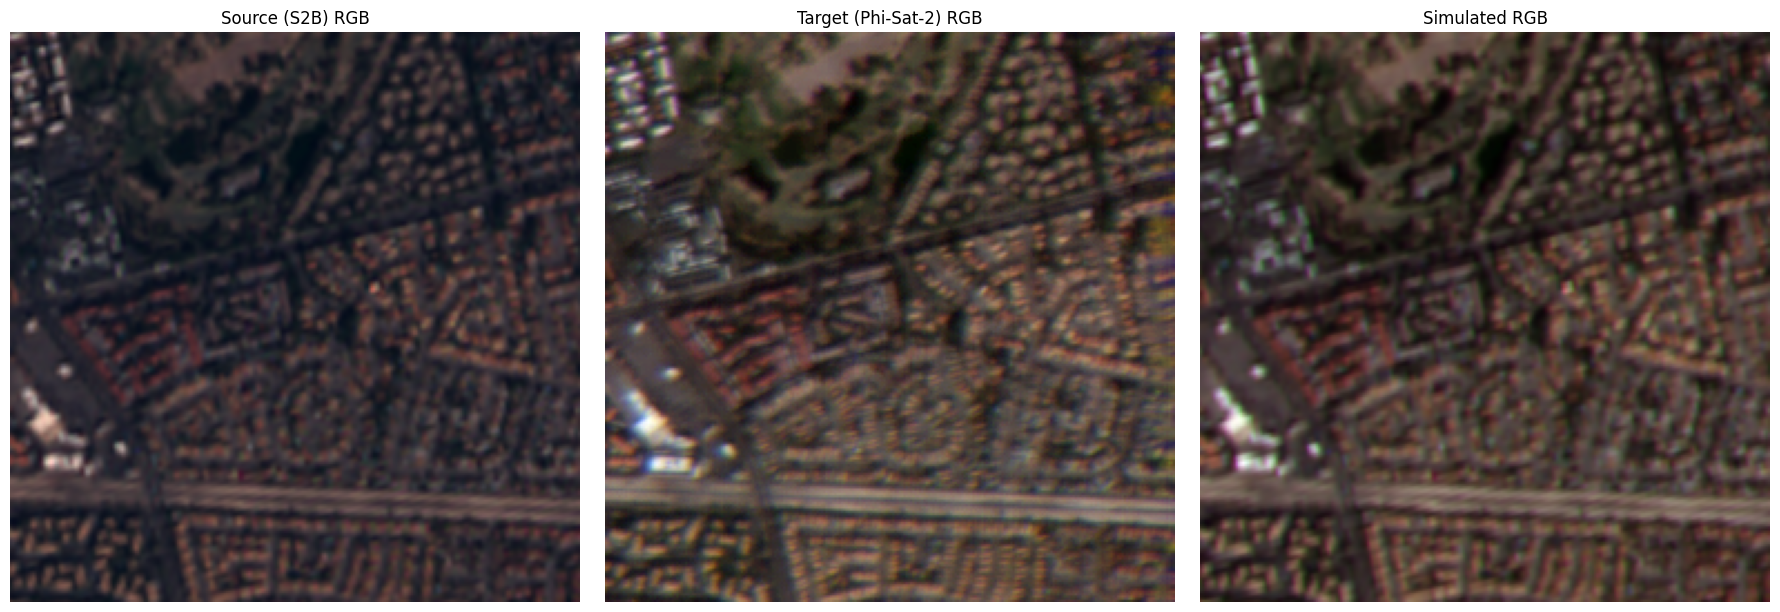

In [6]:
import numpy as np

def normalize(img):
    # Standard normalization for Sentinel-2B
    img = img.cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    return img.transpose(1, 2, 0)

def normalize_phisat(img):
    # Apply recommended PhiSat-2 transformation:
    # 1. Square root of positive values
    # 2. Clip at sqrt(1500) = 38.729
    # 3. Min-Max normalization for visualization
    img = img.cpu().numpy()
    img = np.sqrt(np.maximum(img, 0))
    
    # Per-band clipping for better color balance
    # real/images bands: 0:PAN, 1:B, 2:G, 3:R, 4:RE1, 5:RE2, 6:RE3, 7:NIR
    # So index 3, 2, 1 are R, G, B
    
    # Normalize each channel individually to [0, 1] for visualization
    for i in range(img.shape[0]):
        c_min = img[i].min()
        c_max = img[i].max()
        if c_max > c_min:
            img[i] = (img[i] - c_min) / (c_max - c_min)
            
    return img.transpose(1, 2, 0)

plt.figure(figsize=(18, 6))

# Sentinel-2B RGB (Indices 2, 1, 0 correspond to B04, B03, B02)
plt.subplot(1, 3, 1)
plt.imshow(normalize(source_img[0, [2, 1, 0]]))
plt.title("Source (S2B) RGB")
plt.axis('off')

# PhiSat-2 RGB (Indices 3, 2, 1 correspond to R, G, B in real/images)
plt.subplot(1, 3, 2)
# Note: target_img contains 8 bands (0 to 7)
# Index 3: R, 2: G, 1: B
plt.imshow(normalize_phisat(target_img[0, [3, 2, 1]]))
plt.title("Target (Phi-Sat-2) RGB")
plt.axis('off')

# Simulated
plt.subplot(1, 3, 3)
plt.imshow(normalize_phisat(sim_img[0, [3, 2, 1]]))
plt.title("Simulated RGB")
plt.axis('off')


plt.tight_layout()
plt.show()

# 4. Extract Embedding Layer Tensors
Pass the images through the encoder and extract the feature vectors from the final transformer layer outputs.

In [81]:
with torch.no_grad():
    # Base Model Embeddings
    source_seq = encoder(source_img)[-1]
    target_seq = encoder(target_img)[-1]
    source_emb = source_seq.mean(dim=1).squeeze(0)
    target_emb = target_seq.mean(dim=1).squeeze(0)

    # Fine-tuned Model Embeddings
    source_seq_sim = encoder_sim(source_img)[-1]
    target_seq_sim = encoder_sim(target_img)[-1]
    source_emb_sim = source_seq_sim.mean(dim=1).squeeze(0)
    target_emb_sim = target_seq_sim.mean(dim=1).squeeze(0)

print(f"Sequence shape (Base): {source_seq.shape}")
print(f"Aggregated embedding shape (Base): {source_emb.shape}")
print(f"Aggregated embedding shape (Sim-FT): {source_emb_sim.shape}")

Sequence shape (Base): torch.Size([1, 256, 192])
Aggregated embedding shape (Base): torch.Size([192])
Aggregated embedding shape (Sim-FT): torch.Size([192])


# 5. Calculate Cosine Similarity
Compute the similarity between the two embedding vectors using the formula: $$S_C(A, B) = \frac{A \cdot B}{\|A\| \|B\|}$$

In [82]:
similarity_base = F.cosine_similarity(source_emb.unsqueeze(0), target_emb.unsqueeze(0)).item()
similarity_sim = F.cosine_similarity(source_emb_sim.unsqueeze(0), target_emb_sim.unsqueeze(0)).item()

print(f"Cosine Similarity (Base Model):      {similarity_base:.4f}")
print(f"Cosine Similarity (Fine-tuned Sim): {similarity_sim:.4f}")

improvement = (similarity_sim - similarity_base)
print(f"Improvement: {improvement:+.4f}")

Cosine Similarity (Base Model):      0.9689
Cosine Similarity (Fine-tuned Sim): 0.8555
Improvement: -0.1134


# 6. Plot Embedding Visualizations
Visualize the embedding feature maps for both domains. We plot the token feature matrix (where rows are tokens/patches and columns are feature dimensions).

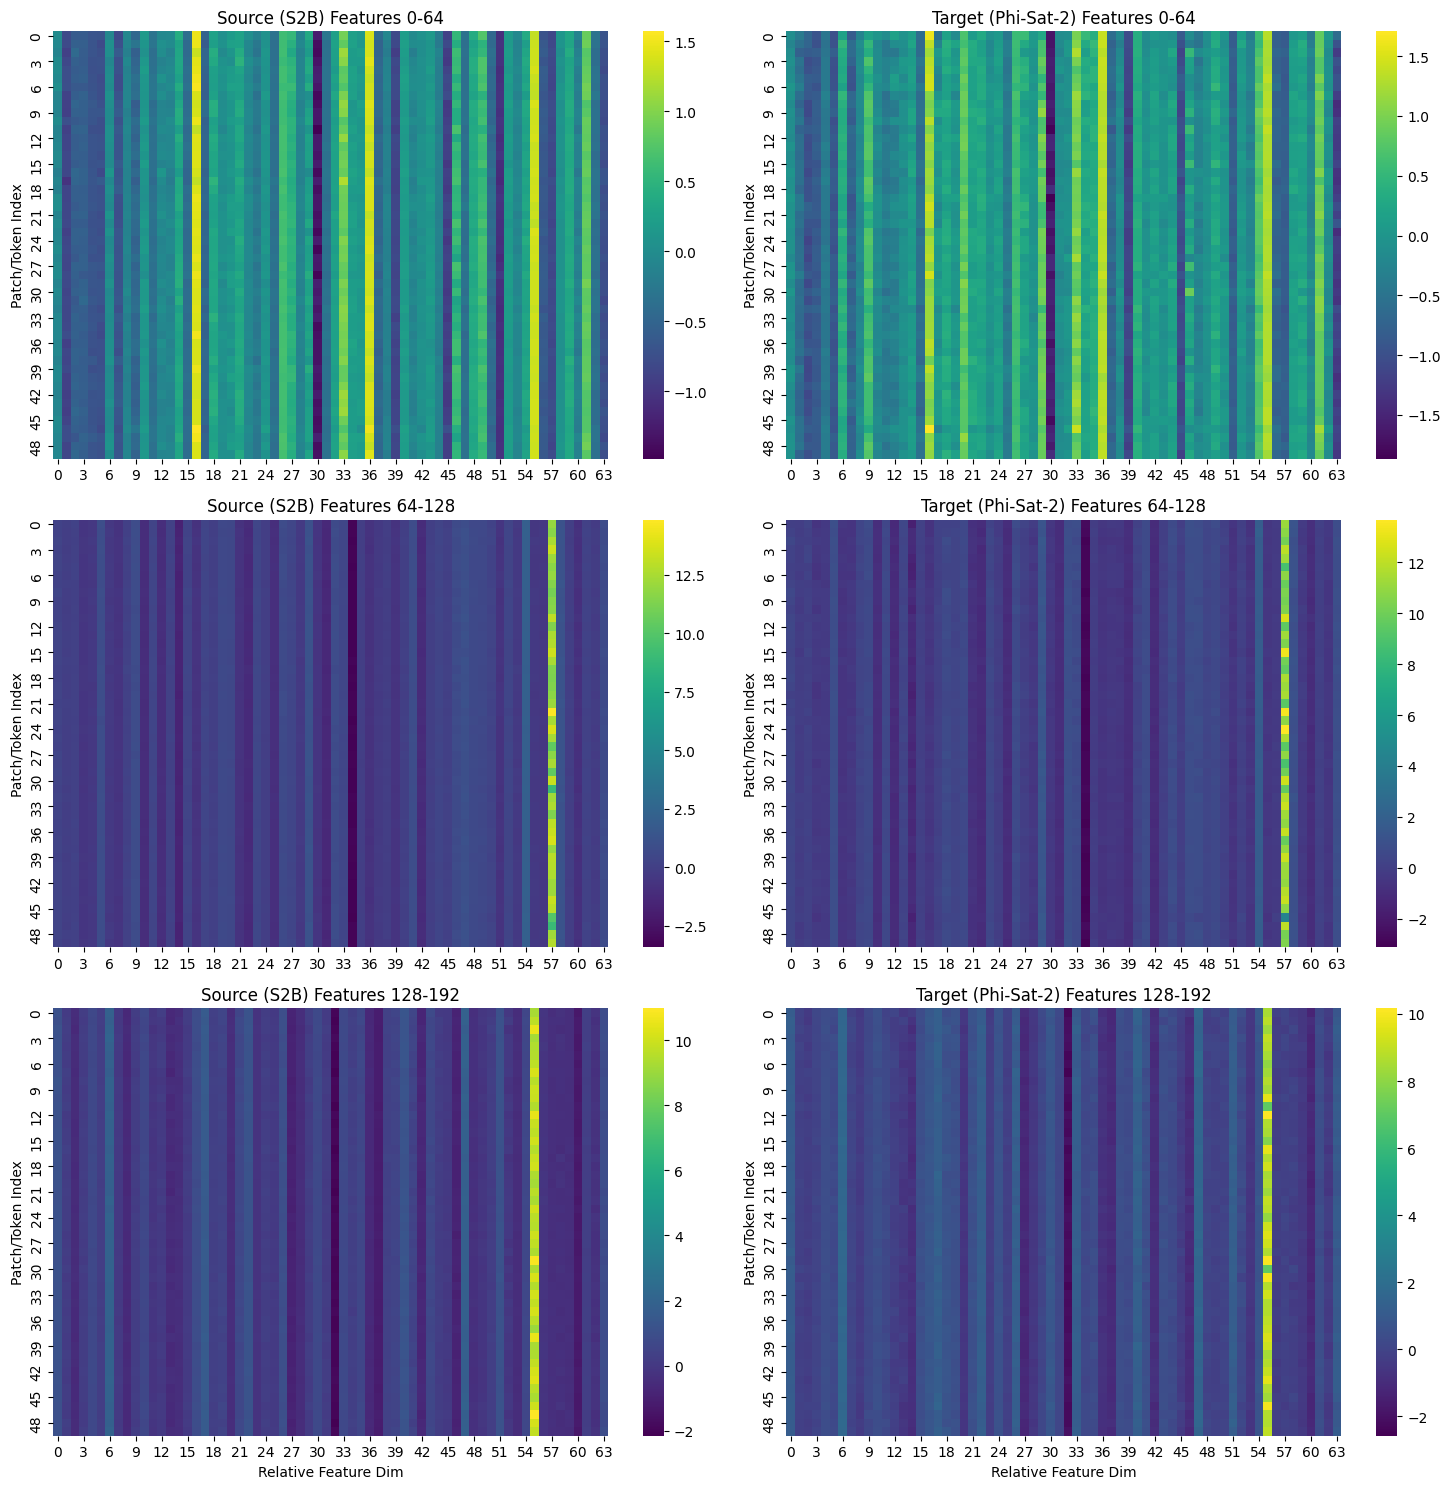

In [ ]:
# Get sequence as numpy for plotting (taking first 50 tokens)
n_tokens = 50
n_features = source_seq.shape[2] # 192
n_groups = 2 # Reduced for side-by-side comparison
feat_per_group = n_features // n_groups

source_np = source_seq[0, :n_tokens, :].cpu().numpy()
target_np = target_seq[0, :n_tokens, :].cpu().numpy()
source_sim_np = source_seq_sim[0, :n_tokens, :].cpu().numpy()
target_sim_np = target_seq_sim[0, :n_tokens, :].cpu().numpy()

fig, axes = plt.subplots(n_groups, 4, figsize=(24, 6 * n_groups))

for group in range(n_groups):
    start_feat = group * feat_per_group
    end_feat = (group + 1) * feat_per_group
    
    # Base Model - Source
    sns.heatmap(source_np[:, start_feat:end_feat], ax=axes[group, 0], cmap="viridis", cbar=False)
    axes[group, 0].set_title(f"Base: S2B (F {start_feat}-{end_feat})")
    
    # Base Model - Target
    sns.heatmap(target_np[:, start_feat:end_feat], ax=axes[group, 1], cmap="viridis", cbar=False)
    axes[group, 1].set_title(f"Base: PhiSat-2 (F {start_feat}-{end_feat})")
    
    # Fine-tuned Model - Source
    sns.heatmap(source_sim_np[:, start_feat:end_feat], ax=axes[group, 2], cmap="viridis", cbar=False)
    axes[group, 2].set_title(f"FT: S2B (F {start_feat}-{end_feat})")
    
    # Fine-tuned Model - Target
    sns.heatmap(target_sim_np[:, start_feat:end_feat], ax=axes[group, 3], cmap="viridis", cbar=False)
    axes[group, 3].set_title(f"FT: PhiSat-2 (F {start_feat}-{end_feat})")

plt.suptitle("Feature Map Comparison: Base vs Fine-tuned Encoder", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 7. Cosine Similarity per Layer
Evaluate how the similarity between domains evolves through the transformer layers.

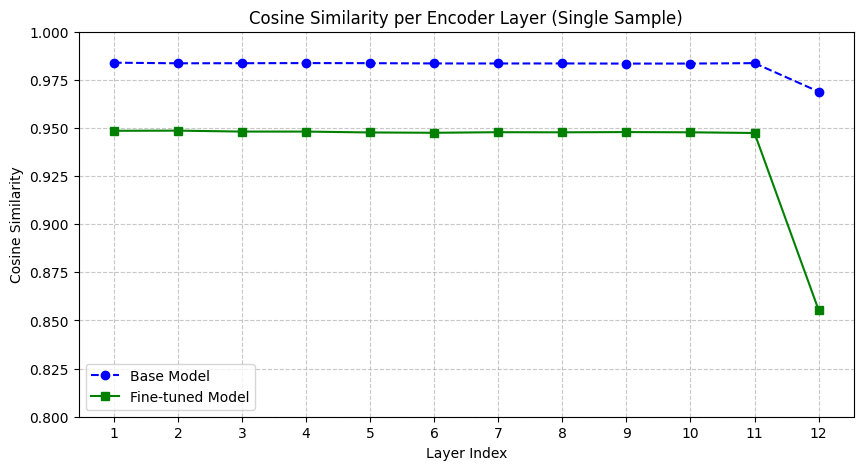

In [83]:
with torch.no_grad():
    source_layers = encoder(source_img)
    target_layers = encoder(target_img)
    source_layers_sim = encoder_sim(source_img)
    target_layers_sim = encoder_sim(target_img)
    
    sims_base = []
    sims_sim = []
    
    for s_feat, t_feat in zip(source_layers, target_layers):
        sim = F.cosine_similarity(s_feat.mean(dim=1), t_feat.mean(dim=1))
        sims_base.append(sim.item())
        
    for s_feat, t_feat in zip(source_layers_sim, target_layers_sim):
        sim = F.cosine_similarity(s_feat.mean(dim=1), t_feat.mean(dim=1))
        sims_sim.append(sim.item())

plt.figure(figsize=(10, 5))
layers = range(1, len(sims_base) + 1)
plt.plot(layers, sims_base, marker='o', linestyle='--', color='b', label='Base Model')
plt.plot(layers, sims_sim, marker='s', linestyle='-', color='g', label='Fine-tuned Model')
plt.title("Cosine Similarity per Encoder Layer (Single Sample)")
plt.xlabel("Layer Index")
plt.ylabel("Cosine Similarity")
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(layers)
plt.ylim(0.8, 1.0)
plt.legend()
plt.show()

# 8. Average Cosine Similarity per Layer (100 Samples)
Analyze the domain similarity across 100 samples to get a statistically significant trend.

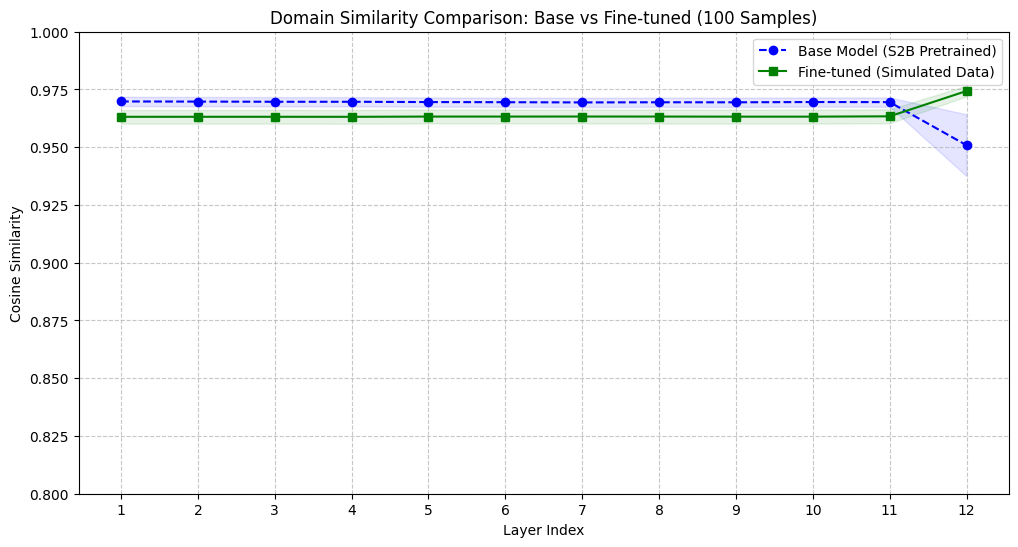

Final Layer Mean Similarity - Base: 0.9509, Fine-tuned: 0.9743
Average Improvement across layers: -0.0039


In [61]:
import numpy as np

num_samples = 100 # Adjusted for faster comparison
all_sims_base = []
all_sims_sim = []

with h5py.File(h5_path, 'r') as f:
    for i in range(min(num_samples, len(f['s2b/images']))):
        # Load sample pair
        s_img = torch.from_numpy(f['sim/images'][i][:8, :, :]).float().unsqueeze(0).to(device)
        t_img = torch.from_numpy(f['real/images'][i][:8, :, :]).float().unsqueeze(0).to(device)
        
        with torch.no_grad():
            # Base Model
            s_layers_base = encoder(s_img)
            t_layers_base = encoder(t_img)
            
            # Sim-FT Model
            s_layers_sim = encoder_sim(s_img)
            t_layers_sim = encoder_sim(t_img)
            
            sample_sims_base = []
            for s_feats, t_feats in zip(s_layers_base, t_layers_base):
                sim = F.cosine_similarity(s_feats.mean(dim=1), t_feats.mean(dim=1))
                sample_sims_base.append(sim.item())
            
            sample_sims_sim = []
            for s_feats, t_feats in zip(s_layers_sim, t_layers_sim):
                sim = F.cosine_similarity(s_feats.mean(dim=1), t_feats.mean(dim=1))
                sample_sims_sim.append(sim.item())
            
            all_sims_base.append(sample_sims_base)
            all_sims_sim.append(sample_sims_sim)

# Convert to numpy
all_sims_base = np.array(all_sims_base)
all_sims_sim = np.array(all_sims_sim)

mean_base = all_sims_base.mean(axis=0)
std_base = all_sims_base.std(axis=0)
mean_sim = all_sims_sim.mean(axis=0)
std_sim = all_sims_sim.std(axis=0)

# Plotting Comparison
plt.figure(figsize=(12, 6))
layers = range(1, len(mean_base) + 1)

# Base
plt.plot(layers, mean_base, marker='o', linestyle='--', color='b', label='Base Model (S2B Pretrained)')
plt.fill_between(layers, mean_base - std_base, mean_base + std_base, alpha=0.1, color='b')

# Sim-FT
plt.plot(layers, mean_sim, marker='s', linestyle='-', color='g', label='Fine-tuned (Simulated Data)')
plt.fill_between(layers, mean_sim - std_sim, mean_sim + std_sim, alpha=0.1, color='g')

plt.title(f"Domain Similarity Comparison: Base vs Fine-tuned ({num_samples} Samples)")
plt.xlabel("Layer Index")
plt.ylabel("Cosine Similarity")
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(layers)
plt.ylim(0.8, 1.0)
plt.legend()
plt.show()

print(f"Final Layer Mean Similarity - Base: {mean_base[-1]:.4f}, Fine-tuned: {mean_sim[-1]:.4f}")
print(f"Average Improvement across layers: {(mean_sim - mean_base).mean():.4f}")

# 9. t-SNE Visualization of Domain Embeddings
Reduce the dimensionality of the aggregated embeddings to 2D using t-SNE to observe the distribution and overlap between Sentinel-2B (Source) and Phi-Sat-2 (Target).

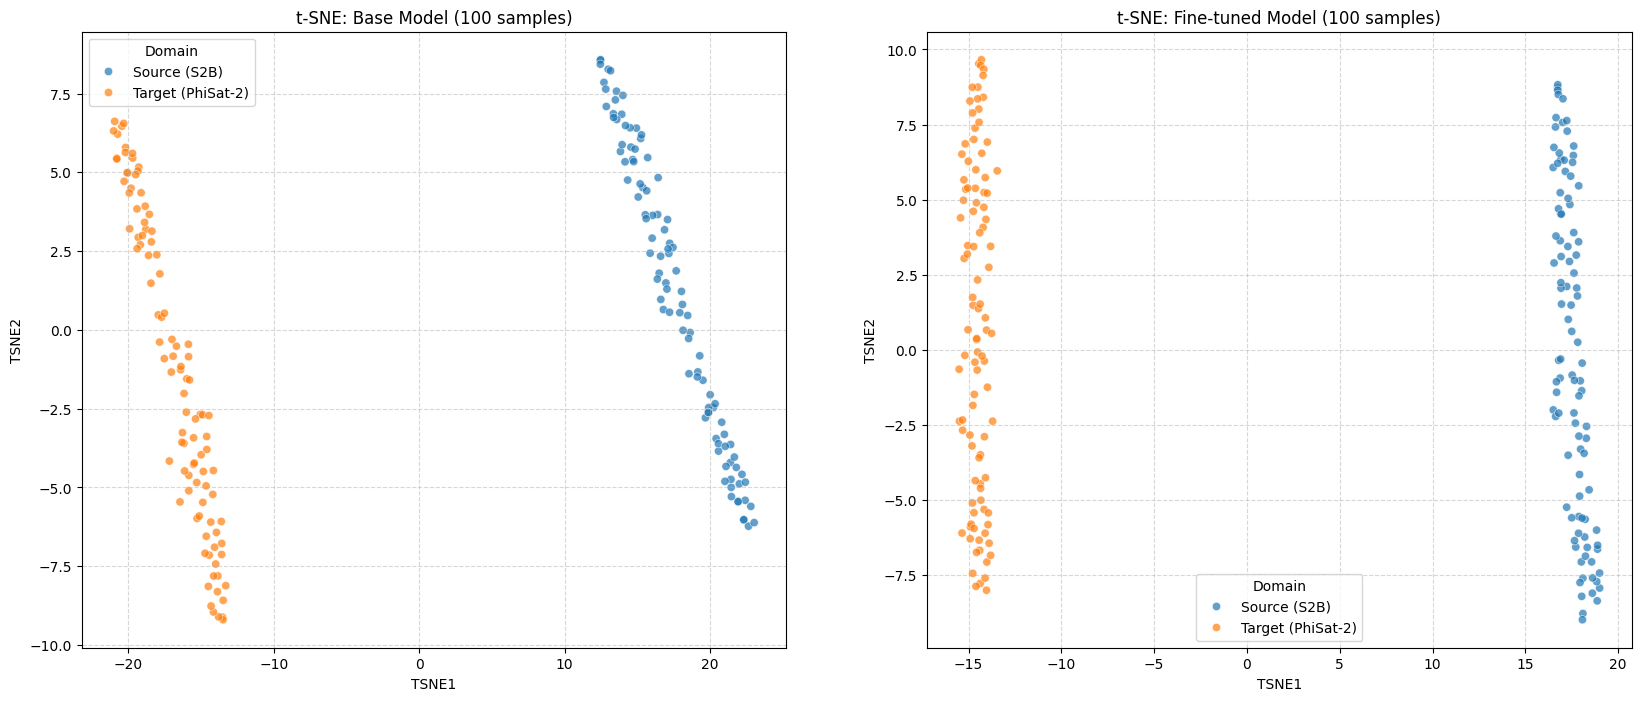

In [62]:
from sklearn.manifold import TSNE
import pandas as pd

tsne_samples = 100
source_base_list, target_base_list = [], []
source_sim_list, target_sim_list = [], []

with h5py.File(h5_path, 'r') as f:
    for i in range(min(tsne_samples, len(f['s2b/images']))):
        s_img = torch.from_numpy(f['sim/images'][i][:8, :, :]).float().unsqueeze(0).to(device)
        t_img = torch.from_numpy(f['real/images'][i][:8, :, :]).float().unsqueeze(0).to(device)
        
        with torch.no_grad():
            # Base Model
            sb = encoder(s_img)[-1].mean(dim=1).cpu().numpy()
            tb = encoder(t_img)[-1].mean(dim=1).cpu().numpy()
            source_base_list.append(sb)
            target_base_list.append(tb)
            
            # FT Model
            ss = encoder_sim(s_img)[-1].mean(dim=1).cpu().numpy()
            ts = encoder_sim(t_img)[-1].mean(dim=1).cpu().numpy()
            source_sim_list.append(ss)
            target_sim_list.append(ts)

def run_tsne(src_list, tgt_list):
    X = np.vstack([np.vstack(src_list), np.vstack(tgt_list)])
    y = ["Source (S2B)"] * len(src_list) + ["Target (PhiSat-2)"] * len(tgt_list)
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
    X_embedded = tsne.fit_transform(X)
    df = pd.DataFrame(X_embedded, columns=['TSNE1', 'TSNE2'])
    df['Domain'] = y
    return df

df_base = run_tsne(source_base_list, target_base_list)
df_sim = run_tsne(source_sim_list, target_sim_list)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.scatterplot(data=df_base, x='TSNE1', y='TSNE2', hue='Domain', alpha=0.7, ax=axes[0])
axes[0].set_title(f"t-SNE: Base Model ({tsne_samples} samples)")
axes[0].grid(True, linestyle='--', alpha=0.5)

sns.scatterplot(data=df_sim, x='TSNE1', y='TSNE2', hue='Domain', alpha=0.7, ax=axes[1])
axes[1].set_title(f"t-SNE: Fine-tuned Model ({tsne_samples} samples)")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.show()

# 10. MMD Score Calculation & Visualization
Define the MMD loss and calculate the discrepancy between source and target feature distributions for a large sample set.

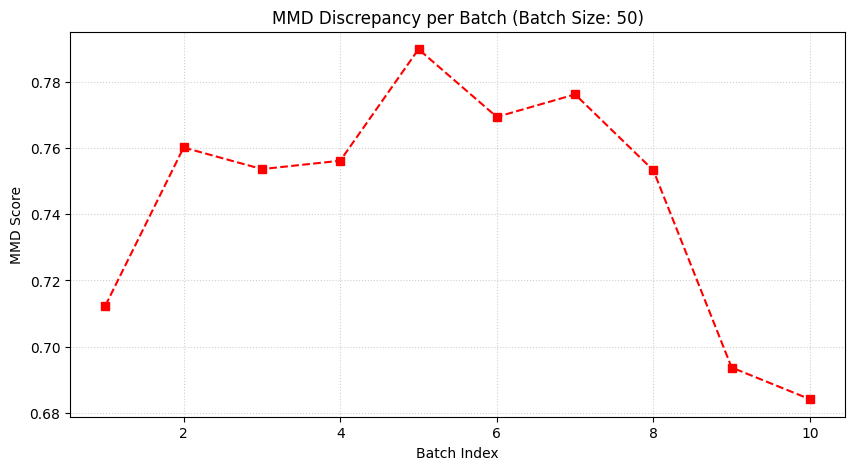

Mean MMD score across 500 samples: 0.744866


In [ ]:
import torch.nn as nn

class RBFKernel(nn.Module):
    def __init__(self, sigmas=[1.0, 2.0, 4.0, 8.0, 16.0]):
        super(RBFKernel, self).__init__()
        self.sigmas = torch.tensor(sigmas).to(device)

    def forward(self, X, Y):
        X_expanded = X.unsqueeze(1)
        Y_expanded = Y.unsqueeze(0)
        dist_squared = torch.sum((X_expanded - Y_expanded) ** 2, dim=2)
        kernel_val = torch.zeros_like(dist_squared)
        for sigma in self.sigmas:
            gamma = 1.0 / (2.0 * sigma ** 2)
            kernel_val += torch.exp(-gamma * dist_squared)
        return kernel_val / len(self.sigmas)

class MMDLoss(nn.Module):
    def __init__(self, sigmas=[1.0, 2.0, 4.0, 8.0, 16.0]):
        super(MMDLoss, self).__init__()
        self.kernel = RBFKernel(sigmas)

    def forward(self, X, Y):
        k_xx = self.kernel(X, X)
        k_yy = self.kernel(Y, Y)
        k_xy = self.kernel(X, Y)
        n, m = X.size(0), Y.size(0)
        mmd_squared = k_xx.sum() / (n * n) + k_yy.sum() / (m * m) - 2.0 * k_xy.sum() / (n * m)
        return torch.relu(mmd_squared)

# Parameters
mmd_samples = 200
batch_size = 50
mmd_criterion = MMDLoss().to(device)
mmd_base, mmd_sim_results = [], []

with h5py.File(h5_path, 'r') as f:
    for i in range(0, mmd_samples, batch_size):
        s_batch, t_batch = [], []
        for j in range(i, min(i + batch_size, mmd_samples)):
            s_batch.append(torch.from_numpy(f['s2b/images'][j]).float())
            t_batch.append(torch.from_numpy(f['real/images'][j][:8, :, :]).float())
        
        s_tensor = torch.stack(s_batch).to(device)
        t_tensor = torch.stack(t_batch).to(device)
        
        with torch.no_grad():
            # Base Model MMD
            sb = encoder(s_tensor)[-1].mean(dim=1)
            tb = encoder(t_tensor)[-1].mean(dim=1)
            mmd_base.append(mmd_criterion(sb, tb).item())
            
            # FT Model MMD
            ss = encoder_sim(s_tensor)[-1].mean(dim=1)
            ts = encoder_sim(t_tensor)[-1].mean(dim=1)
            mmd_sim_results.append(mmd_criterion(ss, ts).item())

# Plotting MMD Comparison
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(mmd_base) + 1), mmd_base, marker='o', linestyle='--', color='b', label='Base Model')
plt.plot(range(1, len(mmd_sim_results) + 1), mmd_sim_results, marker='s', linestyle='-', color='g', label='Fine-tuned Model')
plt.title(f"MMD Discrepancy per Batch (Batch Size: {batch_size})")
plt.xlabel("Batch Index")
plt.ylabel("MMD Score")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

print(f"Mean MMD - Base: {np.mean(mmd_base):.6f}, Fine-tuned: {np.mean(mmd_sim_results):.6f}")
print(f"MMD Reduction: {((np.mean(mmd_base) - np.mean(mmd_sim_results)) / np.mean(mmd_base)) * 100:.2f}%")